# Check data ingestion and raw S&P 500 plots

This notebook performs a small offline visual check of the local raw S&P 500 dataset. It uses the existing `load_market_data` ingestion function and does not change the pipeline data.

## Imports and project paths

Import the analysis libraries and make the project's `src` package available to the notebook.

In [2]:
import sys
sys.executable

'c:\\Users\\anton\\0______MASTER_IN_DATA_SCIENCE\\2_SEMESTRE\\0__________________________MLOPS\\sp500-mlops-pipeline\\.venv\\Scripts\\python.exe'

In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from sp500_mlops_pipeline.pipelines.data_ingestion.nodes import load_market_data

## Load the local raw dataset

Read the committed CSV through the ingestion node. No internet connection or Yahoo Finance request is used.

In [4]:
csv_path = PROJECT_ROOT / "data" / "01_raw" / "sp500_yahoo_finance_raw.csv"
df = load_market_data(csv_path)

## Inspect the imported data

Review a sample of the rows and confirm the dataset dimensions, column names, and imported data types.

In [5]:
display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,1455.219971,931800000
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1399.420044,1009000000
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1402.109985,1085500000
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1403.449951,1092300000
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1441.469971,1225200000


In [6]:
df.shape

(6625, 7)

In [7]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
df.dtypes

## Prepare dates for plotting

Create a notebook-only plotting copy, convert `Date` to datetime, and sort observations chronologically. The ingestion function remains unchanged.

In [8]:
plot_df = df.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.sort_values("Date").reset_index(drop=True)

## Closing price over time

Plot the daily S&P 500 closing price to visually check the long-run market series.

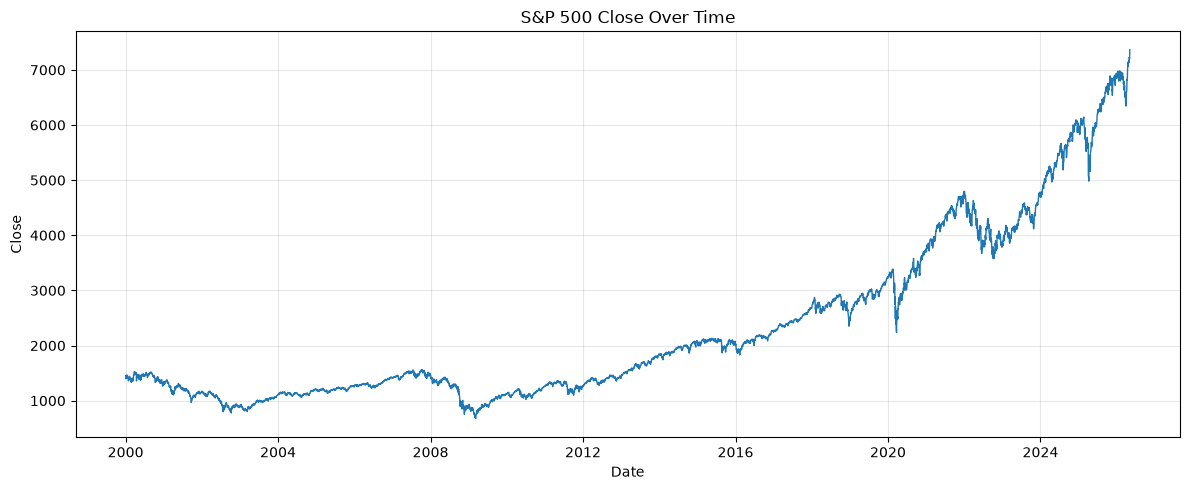

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["Date"], plot_df["Close"], linewidth=1)
ax.set_title("S&P 500 Close Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Adjusted closing price over time

Plot `Adj Close` when it is present in the imported CSV. This keeps the notebook compatible with datasets that do not contain that optional column.

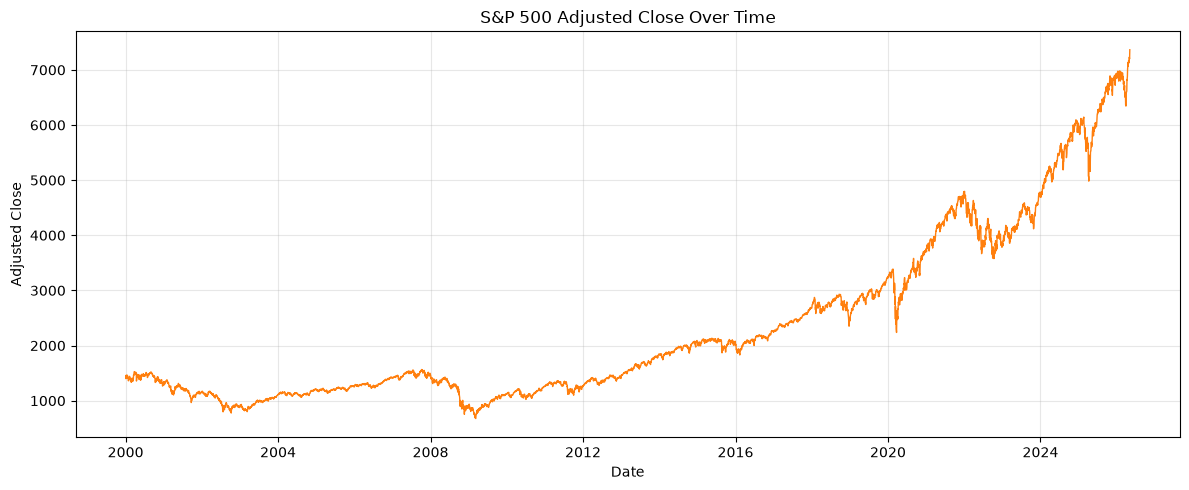

In [10]:
if "Adj Close" in plot_df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["Date"], plot_df["Adj Close"], color="tab:orange", linewidth=1)
    ax.set_title("S&P 500 Adjusted Close Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Adj Close column is not available in this dataset.")

## Trading volume over time

Plot daily trading volume to visually inspect its scale and changes through time.

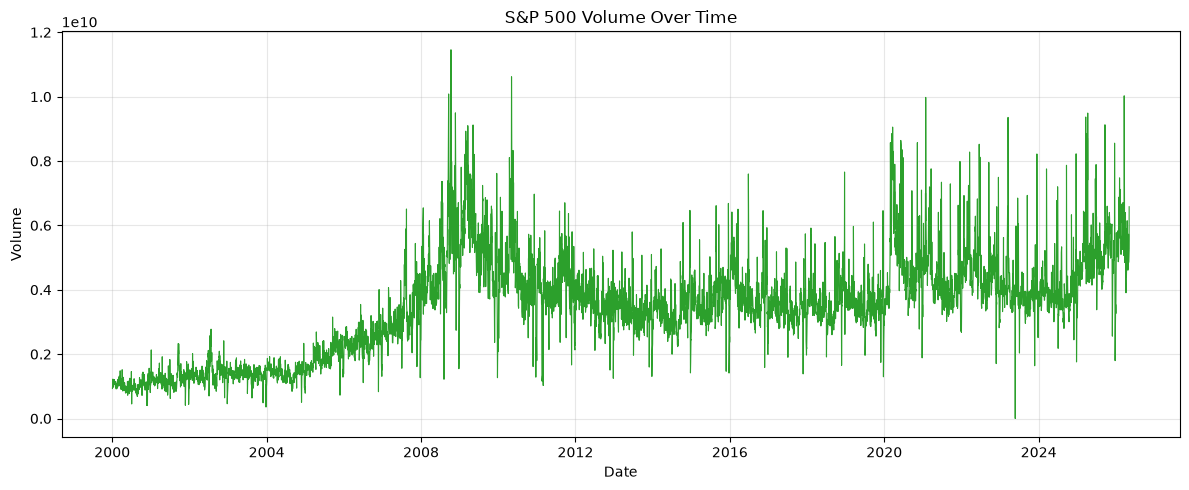

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["Date"], plot_df["Volume"], color="tab:green", linewidth=0.8)
ax.set_title("S&P 500 Volume Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [12]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')